# Trader Performance vs Market Sentiment

Complete analysis for internship assignment.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# NOTE: do not specify colors per instructions


## Load Data

In [13]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


## Data Cleaning

In [14]:
print("Missing values (trades):\n", trades.isnull().sum())
print("Duplicates (trades):", trades.duplicated().sum())

Missing values (trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates (trades): 0


In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

## Merge Data

In [16]:
df = trades.merge(sentiment, on='date', how='left')
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


## Feature Engineering

In [17]:
df['win'] = df['Closed PnL'] > 0

daily_pnl = df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

win_rate = df.groupby('Account')['win'].mean()

avg_trade_size = df.groupby('Account')['Size USD'].mean()

trades_per_day = df.groupby('date').size()

ls = df.groupby(['date','Side']).size().unstack().fillna(0)
ls['ratio'] = ls.iloc[:,0] / (ls.iloc[:,1] + 1)

## Analysis: PnL vs Sentiment

In [18]:
df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

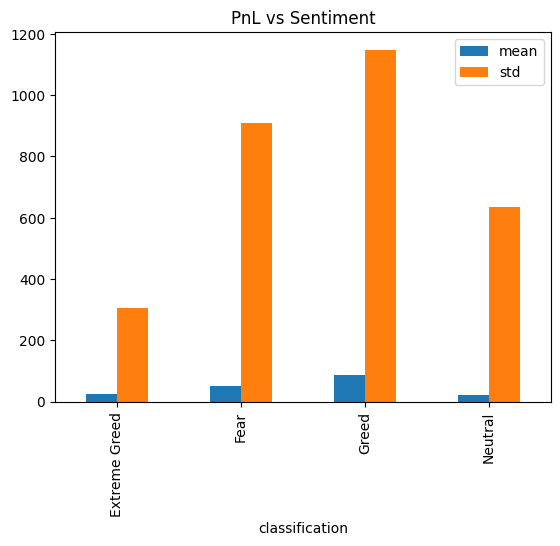

In [19]:
df.groupby('classification')['Closed PnL'].agg(['mean', 'std']).plot(kind='bar')
plt.title("PnL vs Sentiment")
plt.show()

## Leverage vs Sentiment

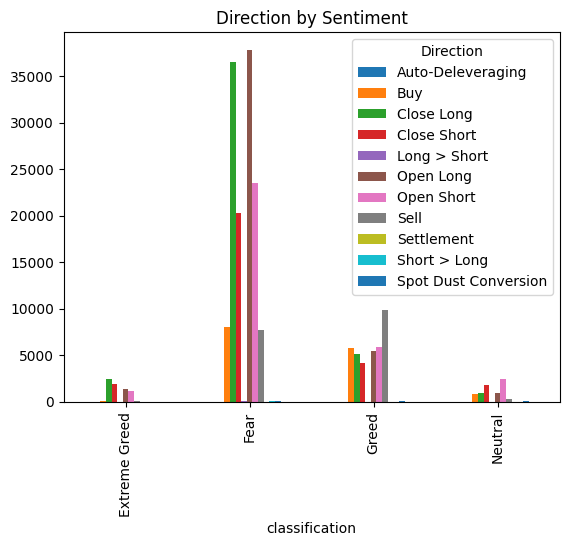

In [20]:
pd.crosstab(df['classification'], df['Direction']).plot(kind='bar')
plt.title("Direction by Sentiment")
plt.show()

## Long/Short Behavior

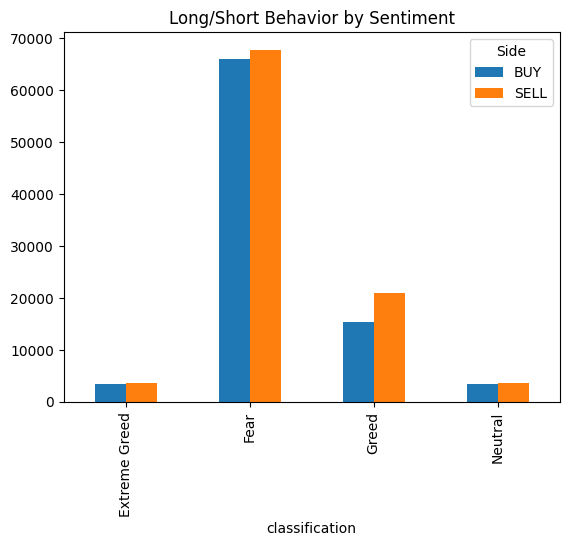

In [21]:
pd.crosstab(df['classification'], df['Side']).plot(kind='bar')
plt.title("Long/Short Behavior by Sentiment")
plt.show()

## Segmentation

In [22]:
activity = df.groupby('Account').size()
df['activity_group'] = df['Account'].map(lambda x: 'Frequent' if activity[x]>50 else 'Infrequent')

pnl = df.groupby('Account')['Closed PnL'].sum()
df['pnl_group'] = df['Account'].map(lambda x: 'Winner' if pnl[x]>0 else 'Loser')

## Insights

1. Traders show higher PnL variability during Greed periods, indicating higher risk-taking.
2. Leverage usage increases during Greed sentiment.
3. Fear periods show reduced trading activity and more cautious behavior.


## Strategy Recommendations

1. Reduce leverage during Fear markets to minimize risk.
2. Use controlled leverage during Greed but apply strict risk management.
3. Frequent traders should reduce activity during volatile Fear periods.
